# 🐼 Pandas 


## 📌 What is Pandas?
Pandas is a Python library used to:
- Work with data in table format
- Clean and analyze data

👉 Think of Pandas as **Excel inside Python**.


In [ ]:
!pip install pandas


In [29]:
import pandas as pd

## 📊 Pandas Series
A **Series** is a one-dimensional data structure (like one column in Excel).

https://pandas.pydata.org/docs/reference/api/pandas.Series.html


In [ ]:
s= pd.Series([10,12,23,34])
print(s)
print(type(s))

### Series with Custom Index


In [ ]:

s = pd.Series([100, 200, 300], index=['a', 'b', 'c'])
s


### Accessing Series Elements


In [ ]:

s = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])
s.loc['a'] #Access by label → use loc



In [ ]:
s.iloc[1] #Access by position → use iloc

### Series Attributes


In [ ]:

s.values


In [ ]:
s.index



In [ ]:
s.dtype

### Arithmetic Operations on Series


In [ ]:

s = pd.Series([10, 20, 30])
s + 5


### Filtering Series


In [ ]:

s = pd.Series([45, 67, 12, 89, 34])
s[s>40]


### apply() Function


In [ ]:

s = pd.Series([1, 2, 3, 4])
s.apply(lambda x:"Even" if x%2 == 0 else "odd")


### Missing Values in Series


In [ ]:

s = pd.Series([10, 20, None, 40])
print(s)
s1 = s.dropna()
print(s1)
s2 = s.fillna(0)
print(s2)
s3 = s.fillna(s.mean())
print(s3)


## 📋 Pandas DataFrame
A **DataFrame** is a table with rows and columns.

https://pandas.pydata.org/docs/reference/frame.html


In [30]:
#From a Dictionary of Lists
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['New York', 'Los Angeles', 'Chicago']
}
df = pd.DataFrame(data)
df



,Name,Age,City
0,Alice,25,New York
1,Bob,30,Los Angeles
2,Charlie,35,Chicago


In [31]:
# #Named Indexes
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['New York', 'Los Angeles', 'Chicago']
}
df = pd.DataFrame(data, index = ["emp1", "emp2", "emp3"])
print(df)




         Name  Age         City
emp1    Alice   25     New York
emp2      Bob   30  Los Angeles
emp3  Charlie   35      Chicago


In [32]:

#From a List of Dictionaries
data = [
    {'Name': 'Alice', 'Age': 25, 'City': 'New York'},
    {'Name': 'Bob', 'Age': 30, 'City': 'Los Angeles'},
    {'Name': 'Charlie', 'Age': 35, 'City': 'Chicago'}
]
df = pd.DataFrame(data)
print(df)


      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago


In [33]:
#From a Dictionary of Series
data = {
    'Name': pd.Series(['Alice', 'Bob', 'Charlie']),
    'Age': pd.Series([25, 30, 35]),
    'City': pd.Series(['New York', 'Los Angeles', 'Chicago'])
}
df = pd.DataFrame(data)
print(df)


      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago


# From Different files:
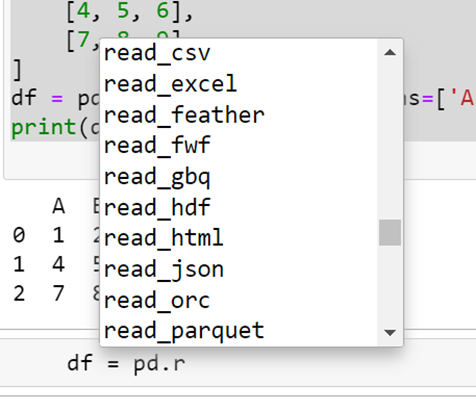


In [35]:
#Read Excel
# import pandas as pd
df = pd.read_excel('Book1.xlsx')
print(type(pd.read_excel('Book1.xlsx')))
df

<class 'pandas.core.frame.DataFrame'>


,Name,age,Emp no
0,Ram,30,574
1,John,30,344
2,Mark,30,434
3,Lata,30,433


In [ ]:
#Read CSV
import pandas as pd
df = pd.read_csv('book2.csv')
print(df)

## 📊 ACCESSING THE DATAFRAME By Column

In [36]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35]
}
df = pd.DataFrame(data)
print(df)



      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   35


In [37]:
# Access a single column
name_column = df['Name']
print(name_column)


0      Alice
1        Bob
2    Charlie
Name: Name, dtype: object


In [41]:
# df['Age'] = df['Age'].replace(26,25)  ## replace individual values with new values

df['Age'] = df['Age'].apply(lambda x: x+1)

df

,Name,Age
0,Alice,26
1,Bob,31
2,Charlie,36


In [42]:
data2 = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Gender': ['F', 'M', 'M']
}
df1 = pd.DataFrame(data2)
print(df1)

      Name Gender
0    Alice      F
1      Bob      M
2  Charlie      M


In [43]:
df['Gender'] = df1['Gender']
df

,Name,Age,Gender
0,Alice,26,F
1,Bob,31,M
2,Charlie,36,M


In [51]:
# Accessing Specific Rows and Columns:
# Access rows 'a' and 'b', and columns 'Name' and 'Age'
df = pd.DataFrame(data, index = ['a','b','c'])

subset = df.loc[['a','b'],['Name','Age']]
print(subset)


    Name  Age
a  Alice   25
b    Bob   30


In [ ]:
# Access a cell by row label and column name
cell = df1.loc['b', 'Age']
print(cell)


# Accessing DataFrame Metadata

In [52]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35]
}
df = pd.DataFrame(data)
print(df)

      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   35


In [54]:

#Getting the Data Types
print(df.dtypes)
#Getting the Shape
print(df.shape)
# Display basic info
print(df.info())

Name    object
Age      int64
dtype: object
(3, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Age     3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes
None


## Combining Dataframes


In [55]:
# SQL like joins are possible in Dataframes
df1 = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["A", "B", "C"]
})

df2 = pd.DataFrame({
    "id": [1, 2, 4],
    "salary": [5000, 6000, 7000]
})

merged = pd.merge(df1, df2, on="id", how="inner") # how options: inner, left, right, outer
print(merged)

   id name  salary
0   1    A    5000
1   2    B    6000


In [56]:
# Use CONCAT to combine DataFrames vertically or horizontally.
pd.concat([df1, df2]) # Rowwise append

,id,name,salary
0,1,A,NaN
1,2,B,NaN
2,3,C,NaN
0,1,NaN,5000.0
1,2,NaN,6000.0
2,4,NaN,7000.0


In [57]:
pd.concat([df1, df2], axis=1) # Columnwise append

,id,name,id,salary
0,1,A,1,5000
1,2,B,2,6000
2,3,C,4,7000


## 📊 Filtering & Conditions


In [58]:
data = {
    'Name': ['Rahul', 'Anita', 'Amit', 'Neha'],
    'Age': [15, 14, 16, None],
    'Marks': [85, 90, 78, 88]
}
df = pd.DataFrame(data)
df

,Name,Age,Marks
0,Rahul,15.0,85
1,Anita,14.0,90
2,Amit,16.0,78
3,Neha,NaN,88


In [59]:
toppers = df[df['Marks']>80]

print(toppers)

    Name   Age  Marks
0  Rahul  15.0     85
1  Anita  14.0     90
3   Neha   NaN     88


In [60]:

df[(df['Marks'] > 80) & (df['Age'] < 16)]


,Name,Age,Marks
0,Rahul,15.0,85
1,Anita,14.0,90


## 📈 Sorting Data


In [62]:

df.sort_values(by=['Marks'] , ascending=[False]) # default sorting is in the ascending order


,Name,Age,Marks
1,Anita,14.0,90
3,Neha,NaN,88
0,Rahul,15.0,85
2,Amit,16.0,78


## 📦 Grouping Data


In [63]:

df.groupby('Age')['Marks'].sum()


Age
14.0    90
15.0    85
16.0    78
Name: Marks, dtype: int64

In [64]:
data = {
    'Customer': ['Alice', 'Alice', 'Bob', 'Charlie', 'Bob'],
    'Sales': [25, 30, 35, 60, 90]
}
df = pd.DataFrame(data)
print(df)

  Customer  Sales
0    Alice     25
1    Alice     30
2      Bob     35
3  Charlie     60
4      Bob     90


In [67]:
# Total Sales by Customer
df.groupby('Customer')['Sales'].sum()

Customer
Alice       55
Bob        125
Charlie     60
Name: Sales, dtype: int64

## 🧹 Handling Missing Values


In [ ]:

df.isnull()


In [ ]:

df['Age'] = df['Age'].fillna(df['Age'].mean())
df


In [68]:
df.to_csv("data.csv") #write back the cleaned dataframe

## 📝 Practice Questions
1. Create a Series of 5 numbers and filter values greater than 20
2. Create a DataFrame with Name, Age, Marks
3. Sort students by Marks
4. Find average marks using groupby
5. Replace missing values with 0


## ✅ Final Summary
- Series → single column data
- DataFrame → table of data
- Filtering → conditions on data
- Grouping → summary calculations
- Dates & plots → basic analysis
